# 02 - Ridge, Lasso & Elastic Net

Part of Classical ML — Linear Models. Directly motivated by notebook 01's ending: OLS becomes numerically unstable under multicollinearity (condition number exploded ~1.9 million-fold from one near-duplicate feature). This notebook derives the fix, shows it is not a heuristic patch but exact MAP estimation under a prior, and derives the geometric reason Lasso -- unlike Ridge -- produces exact zeros.

**Book references:** MML §9.2.2 (regularization, briefly); ESL §3.4 (Shrinkage Methods) is the canonical, thorough treatment of everything in this notebook.

# Part A - Ridge Regression: Fixing the Singularity Directly

Ridge adds an L2 penalty to the RSS objective: `minimize ||y - Xβ||² + λ||β||²`. Taking the gradient and setting to zero (identical derivation to notebook 01, with one extra term):

```
∇β [RSS(β) + λβᵀβ] = -2Xᵀ(y-Xβ) + 2λβ = 0
                        (XᵀX + λI)β = Xᵀy
                                  β = (XᵀX + λI)⁻¹ Xᵀy
```

Adding `λI` before inverting is exactly what fixes the singularity from notebook 01 — a small positive value on every diagonal entry guarantees invertibility regardless of how close to singular `XᵀX` already was.

In [1]:
import numpy as np
from sklearn.linear_model import Ridge

rng = np.random.default_rng(0)
n, p = 100, 5
X = rng.normal(size=(n, p))
true_beta = np.array([3.0, 0, -2.0, 0, 1.5])   # two TRUE zero coefficients -- important for Part C
y = X @ true_beta + rng.normal(scale=1.0, size=n)

lam = 2.0
beta_ridge_closed = np.linalg.inv(X.T @ X + lam * np.eye(p)) @ X.T @ y
sk_ridge = Ridge(alpha=lam, fit_intercept=False).fit(X, y)
print("ridge closed-form:", beta_ridge_closed)
print("sklearn ridge:     ", sk_ridge.coef_)
print("match:", np.allclose(beta_ridge_closed, sk_ridge.coef_, atol=1e-6))

ridge closed-form: [ 2.85688195  0.09249595 -1.89567778  0.02856428  1.50001402]
sklearn ridge:      [ 2.85688195  0.09249595 -1.89567778  0.02856428  1.50001402]
match: True


In [2]:
# Directly confirm this fixes notebook 01's numerical instability
X_bad = np.column_stack([X, X[:, 0]*0.999 + rng.normal(scale=0.001, size=n)])   # near-duplicate column
cond_raw = np.linalg.cond(X_bad.T @ X_bad)
cond_ridge = np.linalg.cond(X_bad.T @ X_bad + lam * np.eye(X_bad.shape[1]))
print(f"condition number WITHOUT ridge: {cond_raw:,.0f}")
print(f"condition number WITH ridge (λ={lam}): {cond_ridge:,.2f}")
print(f"improvement: {cond_raw/cond_ridge:,.0f}x more well-conditioned")

condition number WITHOUT ridge: 3,800,445
condition number WITH ridge (λ=2.0): 94.41
improvement: 40,255x more well-conditioned


# Part B - Ridge Is Not a Heuristic: It Is Exact MAP Estimation

Statistics notebook 02 established MAP = MLE + a prior. Here is the concrete instance: assume a Gaussian likelihood for the noise and a **Gaussian prior** `β ~ N(0, τ²I)` on the coefficients. The negative log posterior is:

```
-log p(β|y) ∝ (1/2σ²)||y-Xβ||² + (1/2τ²)||β||² + const
```

This is *exactly* the ridge objective, with `λ = σ²/τ²`. Ridge regression is not an ad-hoc fix for instability — it is the exact Bayesian MAP estimate under a Gaussian belief that coefficients are probably small, verified numerically below by optimizing the posterior directly and confirming it matches the closed-form ridge solution.

In [3]:
from scipy.optimize import minimize

sigma2 = 1.0    # noise variance (assumed known for this demo)
tau2 = 0.5      # prior variance on beta

def neg_log_posterior(beta):
    return (1/(2*sigma2)) * np.sum((y - X@beta)**2) + (1/(2*tau2)) * np.sum(beta**2)

result = minimize(neg_log_posterior, np.zeros(p), method="BFGS")
beta_map = result.x

lam_equivalent = sigma2 / tau2                                    # the derived relationship
beta_ridge_equiv = np.linalg.inv(X.T @ X + lam_equivalent * np.eye(p)) @ X.T @ y

print("MAP via direct posterior optimization:", beta_map)
print("Ridge closed-form, λ = σ²/τ²:         ", beta_ridge_equiv)
print("exactly the same estimator:", np.allclose(beta_map, beta_ridge_equiv, atol=1e-4))

MAP via direct posterior optimization: [ 2.85688193  0.09249595 -1.8956778   0.02856426  1.500014  ]
Ridge closed-form, λ = σ²/τ²:          [ 2.85688195  0.09249595 -1.89567778  0.02856428  1.50001402]
exactly the same estimator: True


# Part C - Lasso: L1 Penalty, No Closed Form, and Coordinate Descent

Lasso uses an L1 penalty: `minimize ||y-Xβ||² + λ||β||₁`. Because `|β|` is not differentiable at 0, there is no closed-form solution — the standard approach is **coordinate descent**: optimize one coefficient at a time, holding the others fixed, using the soft-thresholding operator that falls out of the L1 subgradient condition.

In [4]:
def soft_threshold(x, lam):
    return np.sign(x) * np.maximum(np.abs(x) - lam, 0)

def lasso_coord_descent(X, y, alpha, n_iter=300):
    # matches sklearn's exact objective convention: (1/(2n))||y-Xw||^2 + alpha*||w||_1
    n, p = X.shape
    beta = np.zeros(p)
    col_norm_sq = (X**2).sum(axis=0) / n
    for _ in range(n_iter):
        for j in range(p):
            residual = y - X @ beta + X[:, j] * beta[j]     # residual excluding feature j
            rho = (X[:, j] @ residual) / n
            beta[j] = soft_threshold(rho, alpha) / col_norm_sq[j]
    return beta

from sklearn.linear_model import Lasso

alpha = 0.5
beta_scratch = lasso_coord_descent(X, y, alpha)
sk_lasso = Lasso(alpha=alpha, fit_intercept=False, max_iter=5000).fit(X, y)
print("scratch coordinate descent:", beta_scratch)
print("sklearn:                   ", sk_lasso.coef_)
print("match:", np.allclose(beta_scratch, sk_lasso.coef_, atol=1e-3))

scratch coordinate descent: [ 2.30046678  0.         -1.28533653 -0.          1.06267847]
sklearn:                    [ 2.30046676  0.         -1.28533652 -0.          1.06267847]
match: True


# Part D - Why Lasso Gives Exact Zeros and Ridge Doesn't: the Geometry

Reframe both penalties as hard constraints: `minimize RSS(β)` subject to `||β||₂ ≤ t` (Ridge) or `||β||₁ ≤ t` (Lasso). The solution is where the RSS contours first touch the constraint region's boundary. A **circle** (L2) has no corners — the tangent point can land anywhere on its boundary, essentially never exactly on an axis. A **diamond** (L1) has corners sitting exactly ON the axes, and because the RSS contours are typically not perfectly aligned with the diamond's flat edges, the first point of contact is disproportionately likely to be at a corner — where one or more coefficients are exactly zero.

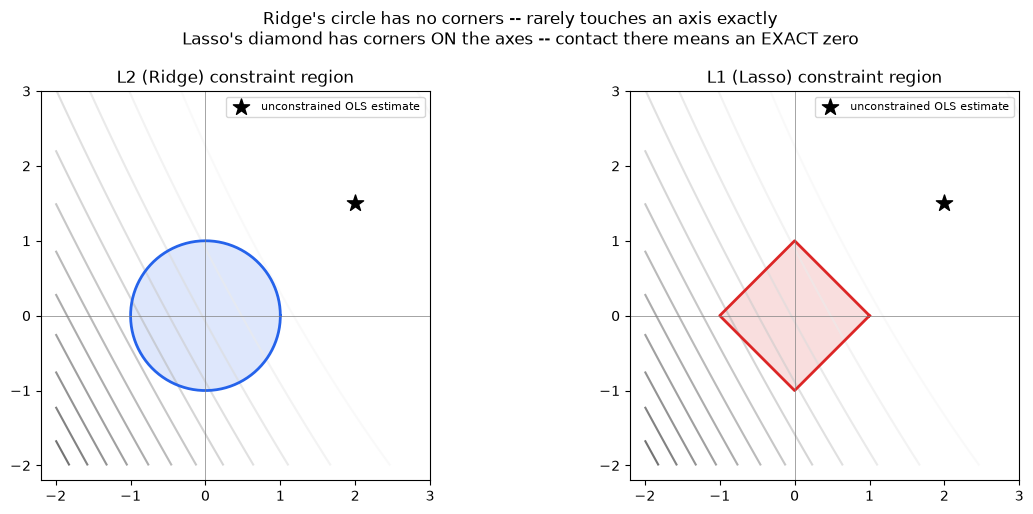

In [5]:
import matplotlib.pyplot as plt
from pathlib import Path
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

b1 = np.linspace(-2, 3, 300); b2 = np.linspace(-2, 3, 300)
B1, B2 = np.meshgrid(b1, b2)
beta_hat = np.array([2.0, 1.5])
A = np.array([[3, 1.5], [1.5, 1]])       # positive definite -- elongated, tilted RSS contours
diff = np.stack([B1 - beta_hat[0], B2 - beta_hat[1]], axis=-1)
RSS = np.einsum('...i,ij,...j->...', diff, A, diff)

t = 1.0
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, kind in zip(axes, ["L2 (Ridge)", "L1 (Lasso)"]):
    ax.contour(B1, B2, RSS, levels=15, cmap="Greys", alpha=0.6)
    if kind.startswith("L2"):
        theta = np.linspace(0, 2*np.pi, 200)
        ax.plot(t*np.cos(theta), t*np.sin(theta), color="#2563eb", linewidth=2)
        ax.fill(t*np.cos(theta), t*np.sin(theta), color="#2563eb", alpha=0.15)
    else:
        diamond = np.array([[t,0],[0,t],[-t,0],[0,-t],[t,0]])
        ax.plot(diamond[:,0], diamond[:,1], color="#dc2626", linewidth=2)
        ax.fill(diamond[:,0], diamond[:,1], color="#dc2626", alpha=0.15)
    ax.scatter(*beta_hat, color="black", marker="*", s=150, zorder=5, label="unconstrained OLS estimate")
    ax.set_xlim(-2.2, 3); ax.set_ylim(-2.2, 3); ax.set_aspect("equal")
    ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
    ax.set_title(f"{kind} constraint region"); ax.legend(fontsize=8)
fig.suptitle("Ridge's circle has no corners -- rarely touches an axis exactly\nLasso's diamond has corners ON the axes -- contact there means an EXACT zero")
fig.tight_layout()
fig.savefig(FIG_DIR / "l1_vs_l2_geometry.png", dpi=140)
plt.show()

## Confirmed directly: coefficient paths across a range of λ

Both true-zero coefficients (`β₁` and `β₃` in our data) should shrink toward zero as `λ` grows. The geometric argument predicts Lasso reaches *exactly* zero; Ridge only approaches it.

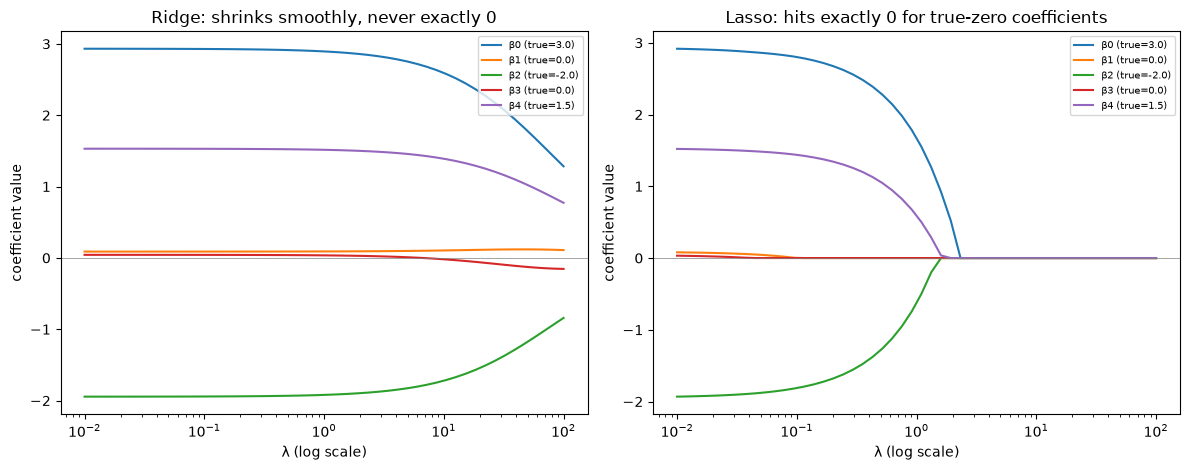

at λ=1.10:
Lasso at true-zero positions: [ 0. -0.] -- EXACTLY zero: True
Ridge at true-zero positions: [0.09077415 0.0349593 ] -- exactly zero: False


In [6]:
alphas = np.logspace(-2, 2, 50)
ridge_coefs = np.array([Ridge(alpha=a, fit_intercept=False).fit(X, y).coef_ for a in alphas])
lasso_coefs = np.array([Lasso(alpha=a, fit_intercept=False, max_iter=5000).fit(X, y).coef_ for a in alphas])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for j in range(p):
    axes[0].plot(alphas, ridge_coefs[:, j], label=f"β{j} (true={true_beta[j]})")
    axes[1].plot(alphas, lasso_coefs[:, j], label=f"β{j} (true={true_beta[j]})")
for ax, title in zip(axes, ["Ridge: shrinks smoothly, never exactly 0", "Lasso: hits exactly 0 for true-zero coefficients"]):
    ax.set_xscale("log"); ax.set_xlabel("λ (log scale)"); ax.set_ylabel("coefficient value")
    ax.set_title(title); ax.legend(fontsize=7); ax.axhline(0, color="gray", lw=0.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "coefficient_paths.png", dpi=140)
plt.show()

idx_true_zero = [1, 3]
lasso_mid, ridge_mid = lasso_coefs[25], ridge_coefs[25]
print(f"at λ={alphas[25]:.2f}:")
print("Lasso at true-zero positions:", lasso_mid[idx_true_zero], "-- EXACTLY zero:", np.allclose(lasso_mid[idx_true_zero], 0, atol=1e-10))
print("Ridge at true-zero positions:", ridge_mid[idx_true_zero], "-- exactly zero:", np.allclose(ridge_mid[idx_true_zero], 0, atol=1e-10))

# Part E - Elastic Net, and the Bias-Variance Tradeoff

**Elastic Net** combines both penalties: `λ₁||β||₁ + λ₂||β||₂²`. Motivation: plain Lasso, applied to a group of highly correlated features, tends to arbitrarily pick ONE of them and zero out the rest — an unstable, somewhat arbitrary selection. Elastic Net's added L2 term tends to keep or drop correlated features together, trading a little of Lasso's sparsity for more stability.

**The bias-variance framing** (Statistics notebook 03, directly reused): every regularization strength `λ` above zero introduces bias (the estimate is pulled away from the unconstrained OLS optimum) in exchange for reduced variance (the estimate is less sensitive to noise in the training data) — regularization is a deliberate, quantified move along the bias-variance tradeoff, not a free improvement, and choosing `λ` is exactly choosing a point on that curve.

## Self-check before moving on

- [ ] I can derive the Ridge closed-form solution and explain why adding `λI` fixes the singularity from notebook 01
- [ ] I can derive, and reproduce numerically, why Ridge is exact MAP estimation with a Gaussian prior
- [ ] I can implement Lasso via coordinate descent and explain the soft-thresholding operator's role
- [ ] I can explain, geometrically, why Lasso's diamond constraint produces exact zeros and Ridge's circle does not
- [ ] I can state when Elastic Net is preferred over plain Lasso (correlated feature groups)
- [ ] I can frame regularization strength as a deliberate bias-variance tradeoff, not a free win

Next: `03-logistic-regression-softmax.ipynb`